# 01 — Data Preparation & Smoke Test

**But** : charger le dataset PatchCamelyon, vérifier les splits, et afficher quelques images pour valider que le pipeline de données fonctionne.

> Ce notebook est **indépendant** — il peut tourner après un redémarrage complet de runtime.

## 1. Setup (identique à chaque notebook)

In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/LAAFI_AI-main
except ImportError:
    pass

import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

Mounted at /content/drive
/content/drive/MyDrive/LAAFI_AI-main


In [3]:
import datasets
datasets.logging.set_verbosity_error()

from laafi_ai.config import ExperimentConfig
from laafi_ai.data import PCamDataModule
from laafi_ai.logging_utils import setup_logging
from laafi_ai.cli_train import set_seed

setup_logging()
config = ExperimentConfig.from_yaml('configs/default.yaml')
set_seed(config.seed)

## 2. Charger les DataLoaders

In [4]:
data_module = PCamDataModule(config.data)
train_loader, val_loader, test_loader = data_module.dataloaders()

print(f'Train: {len(train_loader.dataset):,} images')
print(f'Val:   {len(val_loader.dataset):,} images')
print(f'Test:  {len(test_loader.dataset):,} images')

2026-07-06 14:58:55,872 | INFO | laafi_ai.data | Loading dataset 1aurent/PatchCamelyon
2026-07-06 14:58:59,980 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
2026-07-06 14:59:00,233 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/1aurent/PatchCamelyon/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
2026-07-06 14:59:00,485 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/datasets/1aurent/PatchCamelyon/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab/README.md "HTTP/1.1 200 OK"
2026-07-06 14:59:00,741 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/resolve-cache/datasets/1aurent/PatchCamelyon/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab/README.md "HTTP/1.1 200 OK"


README.md:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

2026-07-06 14:59:00,992 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/1aurent/PatchCamelyon/resolve/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab/PatchCamelyon.py "HTTP/1.1 404 Not Found"
2026-07-06 14:59:01,689 | INFO | httpx | HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/1aurent/PatchCamelyon/1aurent/PatchCamelyon.py "HTTP/1.1 404 Not Found"
2026-07-06 14:59:01,948 | INFO | httpx | HTTP Request: GET https://huggingface.co/api/datasets/1aurent/PatchCamelyon/revision/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab "HTTP/1.1 200 OK"
2026-07-06 14:59:02,197 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/1aurent/PatchCamelyon/resolve/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab/.huggingface.yaml "HTTP/1.1 404 Not Found"
2026-07-06 14:59:02,469 | INFO | httpx | HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=1aurent/PatchCamelyon "HTTP/1.1 200 OK"
2026-07-06 14:59:02,726 | INFO | httpx | HTTP Request:

data/train-00000-of-00013-4717c3cf92578c(…):   0%|          | 0.00/471M [00:00<?, ?B/s]

2026-07-06 14:59:11,660 | INFO | httpx | HTTP Request: HEAD https://huggingface.co/datasets/1aurent/PatchCamelyon/resolve/e4bd149e7a868a9d811fdd9f9a9fb78c05c104ab/data/train-00001-of-00013-549914845b4273b1.parquet "HTTP/1.1 302 Found"


...

data/test-00001-of-00002-3bfa172e8818685(…):   0%|          | 0.00/375M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/262144 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/32768 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/32768 [00:00<?, ? examples/s]

Train: 262,144 images
Val:   32,768 images
Test:  32,768 images


## 3. Smoke test — un batch

In [5]:
images, labels = next(iter(train_loader))
print('Batch shape:', images.shape)
print('Label shape:', labels.shape)
print('Labels (10 premiers):', labels[:10])

Batch shape: torch.Size([32, 3, 224, 224])
Label shape: torch.Size([32])
Labels (10 premiers): tensor([0., 1., 1., 0., 0., 1., 1., 0., 1., 0.])


## 4. Visualiser quelques images

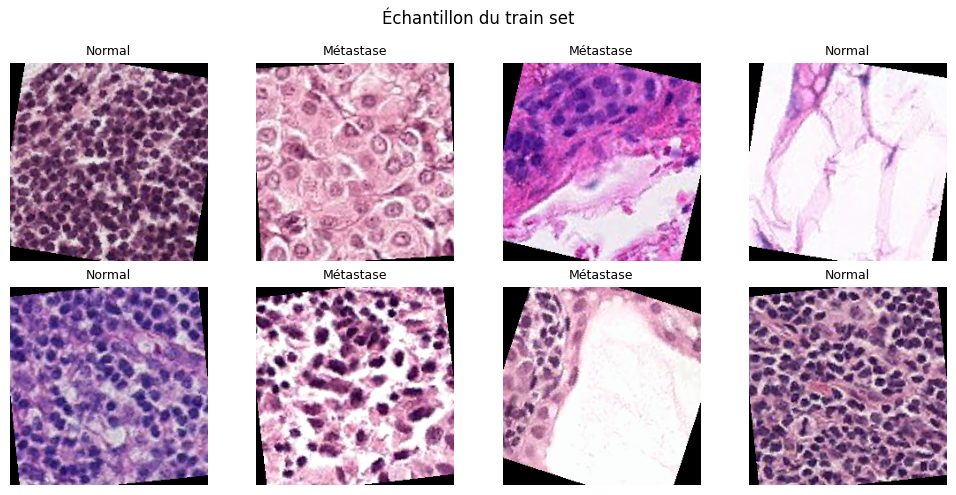

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def denormalize_to_rgb(tensor):
    """Dé-normalise un tensor ImageNet pour affichage."""
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1, 2, 0).numpy()
    return np.clip(img * std + mean, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize_to_rgb(images[i]))
    label_text = 'Métastase' if labels[i] == 1 else 'Normal'
    ax.set_title(label_text, fontsize=9)
    ax.axis('off')
plt.suptitle('Échantillon du train set', fontsize=12)
plt.tight_layout()
plt.show()

---
**Prochain notebook** : `02_train.ipynb` pour lancer l'entraînement (ou reprendre depuis un checkpoint).